In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [23]:
df = pd.read_csv('ifood_df.csv')

In [24]:
df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [26]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


In [27]:
df = df.dropna()

In [28]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [29]:
df['Total_Purchases'] = (
    df['NumDealsPurchases'] +
    df['NumWebPurchases'] +
    df['NumCatalogPurchases'] +
    df['NumStorePurchases']
)

In [30]:
df[['Income', 'Total_Spending', 'Total_Purchases']].describe()

,Income,Total_Spending,Total_Purchases
count,2205.000000,2205.000000,2205.000000
mean,51622.094785,606.821769,14.887982
std,20713.063826,601.675284,7.615277
min,1730.000000,5.000000,0.000000
25%,35196.000000,69.000000,8.000000
50%,51287.000000,397.000000,15.000000
75%,68281.000000,1047.000000,21.000000
max,113734.000000,2525.000000,43.000000


In [31]:
X = df[['Income', 'Total_Spending', 'Total_Purchases']]

In [32]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [33]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

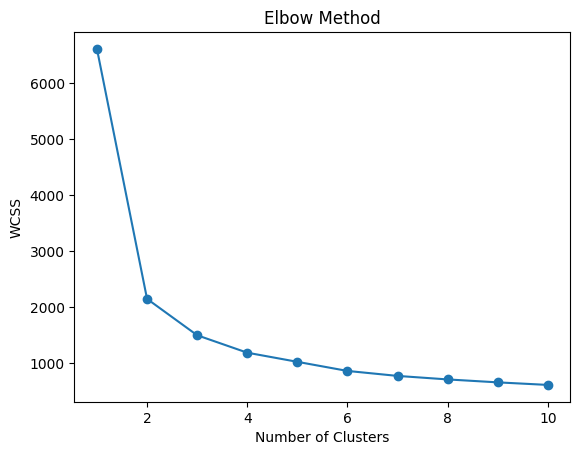

In [34]:
plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

In [35]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [36]:
df[['Income', 'Total_Spending', 'Total_Purchases', 'Cluster']].head()

,Income,Total_Spending,Total_Purchases,Cluster
0,58138.0,1617,25,0
1,46344.0,27,6,1
2,71613.0,776,21,3
3,26646.0,53,8,1
4,58293.0,422,19,2


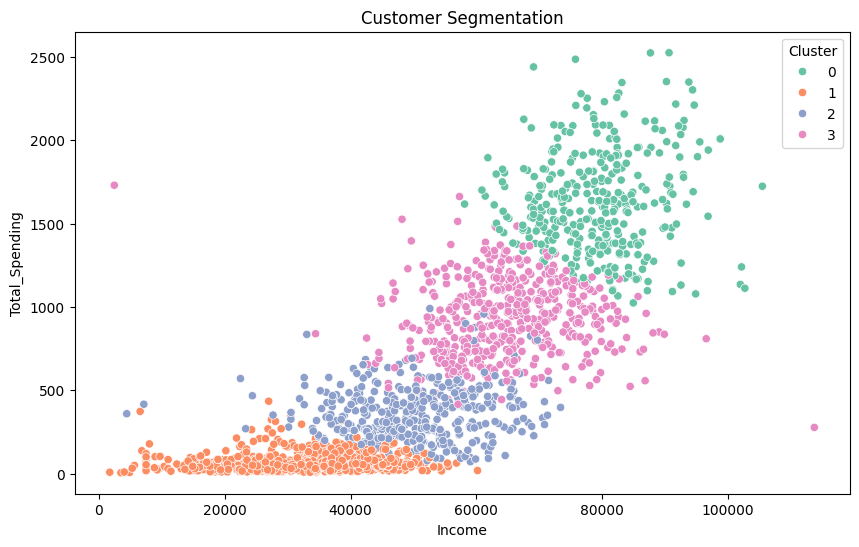

In [37]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Income'],
    y=df['Total_Spending'],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title('Customer Segmentation')

plt.show()

In [38]:
df.groupby('Cluster')[['Income', 'Total_Spending', 'Total_Purchases']].mean()

,Income,Total_Spending,Total_Purchases
Cluster,,,
0,79164.833773,1625.577836,21.013193
1,31323.363095,67.100000,6.926190
2,50027.354911,363.229911,15.321429
3,65240.459108,934.678439,22.643123
